Importing Libraries


In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor




# Data Collection and Processing

In [38]:
# 2.Load Dataset

car_dataset= pd.read_csv('Car details.csv')

In [39]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [40]:
# getting  information about data
car_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [41]:
car_dataset.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [42]:
# checking the number of rows and columns
car_dataset.shape

(8128, 13)

# Data Cleaning


In [43]:
# checking missing values
car_dataset.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [44]:
car_dataset.isnull().sum()/len(car_dataset) *100  #Checking the percentage of null values

name             0.000000
year             0.000000
selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          2.718996
engine           2.718996
max_power        2.645177
torque           2.731299
seats            2.718996
dtype: float64

This dataset have very less null values. It is less than 5% null value, So removing the null values  

In [45]:
car_dataset=car_dataset.dropna()


In [46]:
# checking after removing null values
car_dataset.isnull().sum()/len(car_dataset) *100

name             0.0
year             0.0
selling_price    0.0
km_driven        0.0
fuel             0.0
seller_type      0.0
transmission     0.0
owner            0.0
mileage          0.0
engine           0.0
max_power        0.0
torque           0.0
seats            0.0
dtype: float64

In [47]:
# checking duplicate values 
car_dataset.duplicated().sum()

np.int64(1189)

In [48]:
# delete duplicated
car_dataset=car_dataset.drop_duplicates()

In [49]:
car_dataset.duplicated().sum()

np.int64(0)

# Feature Engineering


In [50]:
cols = car_dataset.select_dtypes(include="string")
cols

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
0,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,Skoda Rapid 1.5 TDI Ambition,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,Honda City 2017-2020 EXi,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)"
3,Hyundai i20 Sportz Diesel,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
4,Maruti Swift VXI BSIII,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"
...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm
8122,Hyundai i20 Magna 1.4 CRDi,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm
8123,Hyundai i20 Magna,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm
8124,Hyundai Verna CRDi SX,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)"


In [51]:
car_dataset['fuel'].value_counts()

fuel
Diesel    3658
Petrol    2973
CNG         51
LPG         35
Name: count, dtype: int64

In [52]:
# checking value count
for col in cols:
    i=car_dataset[col].value_counts()
    print(i)

name
Maruti Swift Dzire VDI                          118
Maruti Alto 800 LXI                              76
Maruti Alto LXi                                  69
Maruti Swift VDI                                 60
Maruti Alto K10 VXI                              47
                                               ... 
Maruti Celerio ZXI AMT BSIV                       1
Tata Bolt Revotron XM                             1
Tata Manza Aura (ABS) Safire BS IV                1
Tata Nexon 1.5 Revotorq XT                        1
Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV      1
Name: count, Length: 1982, dtype: int64
fuel
Diesel    3658
Petrol    2973
CNG         51
LPG         35
Name: count, dtype: int64
seller_type
Individual          6024
Dealer               666
Trustmark Dealer      27
Name: count, dtype: int64
transmission
Manual       6142
Automatic     575
Name: count, dtype: int64
owner
First Owner             4176
Second Owner            1888
Third Owner              493
Fourth & Ab

Convert mileage, engine, max_power to numeric 


In [53]:
car_dataset['mileage'] = car_dataset['mileage'].str.split(' ').str[0].astype(float)
car_dataset['engine'] = car_dataset['engine'].str.replace(' CC', '').astype(float)

In [54]:
# delete unit and convert data type
car_dataset['max_power'] = car_dataset['max_power'].str.replace(' bhp', '')
car_dataset['max_power'] = pd.to_numeric(car_dataset['max_power'], errors='coerce')

Boxplot

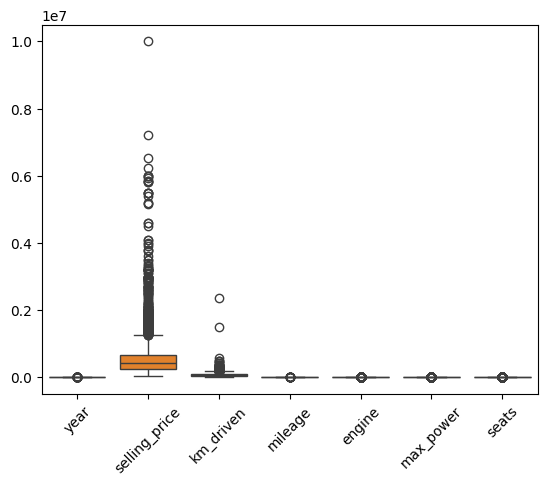

In [55]:
plt.Figure(figsize=(20,10))
sns.boxplot(data=car_dataset)
plt.xticks(rotation=45)
plt.show()

The selling price is showing outlier but it is not actual outlier, it is price of luxurious car ,so not removing. If it is removed it will not predict well on luxury cars

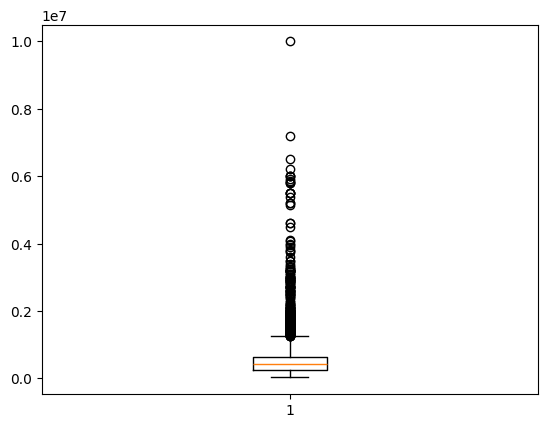

In [56]:
plt.boxplot(x=car_dataset['selling_price'])
plt.show()

In [57]:
car_dataset

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,90Nm@ 3500rpm,5.0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0


Encoding

In [58]:
# create the encoder object
le = LabelEncoder()
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in cat_cols:
    car_dataset[col]= le.fit_transform(car_dataset[col])

In [59]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,1,1,1,0,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,3,1,1,4,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,1,1,0,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,3,1,1,0,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


In [60]:
expensive_cars = car_dataset[car_dataset['selling_price'] > 5000000] # The cars which have price more than 5000000
print(expensive_cars[['name', 'selling_price']])   

                                            name  selling_price
132                                Lexus ES 300h        5150000
136              Mercedes-Benz S-Class S 350 CDI        6000000
139                   BMW X4 M Sport X xDrive20d        5800000
148              Mercedes-Benz S-Class S 350 CDI        5850000
170                Volvo XC90 T8 Excellence BSIV       10000000
384                   BMW X4 M Sport X xDrive20d        5400000
385                   BMW X4 M Sport X xDrive20d        5500000
1071            BMW 6 Series GT 630d Luxury Line        6000000
2938                       BMW X7 xDrive 30d DPE        7200000
4671               BMW 5 Series 520d Luxury Line        5200000
4753            BMW 6 Series GT 630d Luxury Line        5500000
4766            BMW 6 Series GT 630d Luxury Line        6000000
4950                      Audi A6 35 TFSI Matrix        6223000
4951                      Audi A6 35 TFSI Matrix        5923000
4952                      Audi A6 35 TFS

Split Features & Target


In [61]:
X= car_dataset.drop(columns=['selling_price', 'name','torque'])
y=car_dataset['selling_price']

Train-Test Split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling

In [63]:
# preparing preprocessing and model
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)




# Model Training

Linear Regression


In [64]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

Lasso Regression

In [65]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

Random Forest

In [66]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

XG Boost

In [67]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# Evaluation

In [68]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb)
    ]
})

print(results)

               Model  R2 Score            MAE           MSE
0  Linear Regression  0.655769  171880.748871  7.553487e+10
1   Lasso Regression  0.655769  171880.708947  7.553487e+10
2      Random Forest  0.918860   77714.101695  1.780453e+10
3            XGBoost  0.920156   77942.609375  1.752029e+10


In [69]:
results.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,MAE,MSE
3,XGBoost,0.920156,77942.609375,1.752029e+10
2,Random Forest,0.918860,77714.101695,1.780453e+10
1,Lasso Regression,0.655769,171880.708947,7.553487e+10
0,Linear Regression,0.655769,171880.748871,7.553487e+10


# Visualization

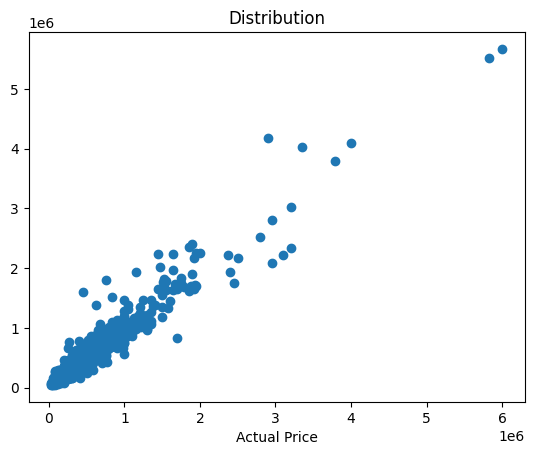

In [70]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.title("Distribution")
plt.show()

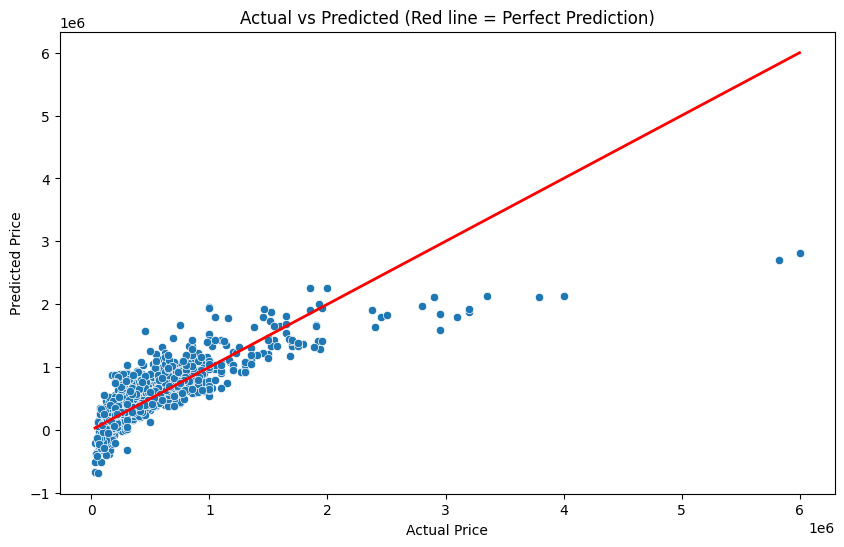

In [71]:

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Red line = Perfect Prediction)")
plt.show()

# Model Comparison Visualization

               Model  R2 Score            MAE           MSE
0  Linear Regression  0.655769  171880.748871  7.553487e+10
1   Lasso Regression  0.655769  171880.708947  7.553487e+10
2      Random Forest  0.918860   77714.101695  1.780453e+10
3            XGBoost  0.920156   77942.609375  1.752029e+10


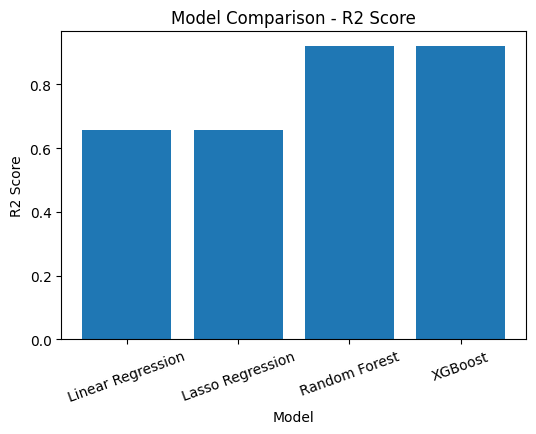

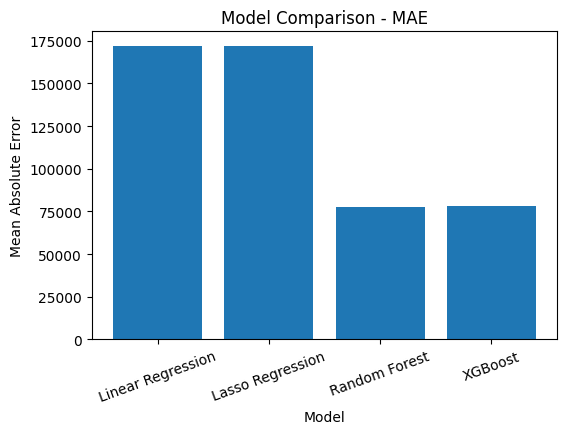

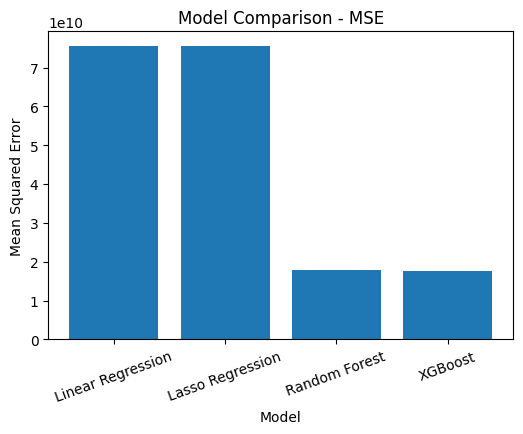

In [72]:

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb)
    ]
})

print(results)



# 1. R2 Score Comparison
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['R2 Score'])
plt.title("Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

# 2. MAE Comparison
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['MAE'])
plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=20)
plt.show()

# 3. MSE Comparison
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['MSE'])
plt.title("Model Comparison - MSE")
plt.xlabel("Model")
plt.ylabel("Mean Squared Error")
plt.xticks(rotation=20)
plt.show()

After implementing and evaluating multiple machine learning models including Linear Regression, Lasso Regression,Random Forest and XGBoost, it was observed that the XGBoost model performed the best among all.

# Feature Importance 

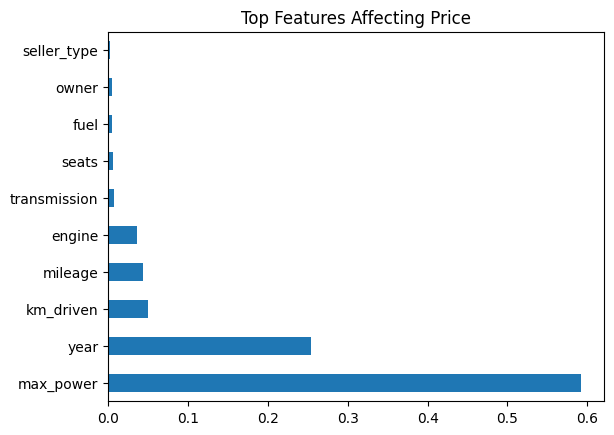

In [73]:
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Price")
plt.show()